# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

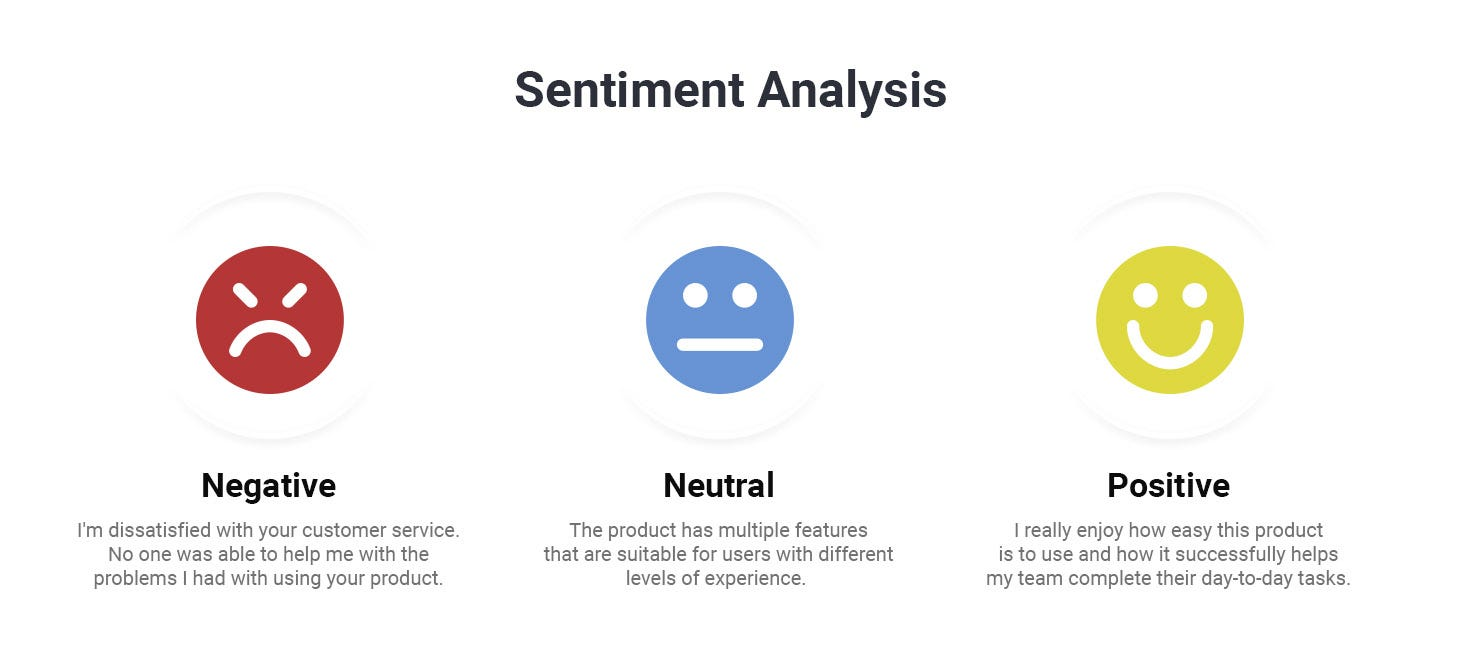

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [1]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

FileNotFoundError: [Errno 2] No such file or directory: '/content/DisneylandReviews.csv'

In [ ]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

## Solving the Amazon Reviews Use Case

We now work through the six tasks laid out above, following the same structure as the Disneyland example: load &rarr; preprocess &rarr; split &rarr; TF-IDF &rarr; train &rarr; evaluate. The only difference here is the classifier (**Naive Bayes** instead of SVM) and an added confusion matrix at the end.

### Task 1: Load the data and apply 5 preprocessing steps

First we load the CSV. It has `Product Name`, `Brand Name`, `Price`, `Rating`, `Reviews`, and `Review Votes` columns — we only need `Reviews` (the review text) and `Rating` (used to derive sentiment, exactly like `Rating` did for the Disneyland reviews).

In [4]:
import pandas as pd

data = pd.read_csv('Amazon_Unlocked_Mobile.csv')
print("Shape:", data.shape)
data.head()


Shape: (413840, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


Check for missing values.

In [4]:
data.isna().sum()


Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

**Preprocessing step 1 — drop missing values.** We only need rows that actually have review text and a rating (`Brand Name`, `Price`, and `Review Votes` aren't used, so their missing values don't matter here).

In [5]:
data = data.dropna(subset=['Reviews', 'Rating']).reset_index(drop=True)
print("Shape after dropping missing reviews/ratings:", data.shape)


Shape after dropping missing reviews/ratings: (413770, 6)


**Map star ratings to sentiment labels**, using the same 3-class scheme as the Disneyland example (`>3` &rarr; positive, `<3` &rarr; negative, `==3` &rarr; neutral).

In [6]:
def sentiment_from_rating(rating):
    if rating > 3:
        return 'positive'
    elif rating < 3:
        return 'negative'
    else:
        return 'neutral'

data['Sentiment'] = data['Rating'].apply(sentiment_from_rating)
data['Sentiment'].value_counts()


Sentiment
positive    284948
negative     97059
neutral      31763
Name: count, dtype: int64

The dataset is fairly imbalanced towards positive reviews (mostly 5-star ratings) — worth keeping in mind when we look at the evaluation metrics later, especially for the *neutral* class.

Now the remaining 4 preprocessing steps, combined into one `preprocess_text` function (steps 2-5):

- **Step 2 — lower-case** the text
- **Step 3 — remove punctuation and special characters** using the regex `[^a-z\s]`, keeping only letters and whitespace
- **Step 4 — remove English stopwords** ("the", "and", "is", ...) using NLTK's stopword list, since they carry little sentiment information but dominate word counts
- **Step 5 — tokenize and rejoin**, splitting on whitespace and rebuilding the cleaned string

This extends the simpler 3-step `preprocess_text` used for the Disneyland reviews above by adding stopword removal, which matters more here since we're using raw word counts (TF-IDF) rather than a language model.

In [7]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()                          # Step 2: lower-case
    text = re.sub(r'[^a-z\s]', '', text)          # Step 3: remove punctuation/special chars
    words = text.split()                          # Step 4 (tokenize first)
    words = [w for w in words if w not in stop_words]  # Step 4: remove stopwords
    return ' '.join(words)                        # Step 5: rejoin cleaned tokens

data['Reviews_clean'] = data['Reviews'].apply(preprocess_text)

# Drop any reviews that became empty after cleaning (e.g. reviews that were only stopwords/punctuation)
data = data[data['Reviews_clean'].str.len() > 0].reset_index(drop=True)

data[['Reviews', 'Reviews_clean', 'Sentiment']].head()


,Reviews,Reviews_clean,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky found used phone us used hard phone...,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,positive
2,Very pleased,pleased,positive
3,It works good but it goes slow sometimes but i...,works good goes slow sometimes good phone love,positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,positive


### Task 2: Train/test split

Same 80/20 split as the Disneyland example, but this time we also pass `stratify=data['Sentiment']` so the train and test sets keep the same positive/negative/neutral proportions — important given how imbalanced the classes are.

In [8]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    data['Reviews_clean'],
    data['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=data['Sentiment']
)

print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")


train_data size: (330133,)
test_data size: (82534,)


### Task 3: Feature extraction using TF-IDF

Same vectorizer setup as the Disneyland example: fit only on the training data, then use it to transform both the training and test sets so no information leaks from the test set into the vocabulary.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=1000)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

print("TF-IDF matrix shape (train):", train_vectors.shape)


TF-IDF matrix shape (train): (330133, 1000)


### Task 4: Train a Naive Bayes classifier

We use `MultinomialNB`, the standard Naive Bayes variant for text/word-count style features like TF-IDF, and fit it on the training vectors and labels.

In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()
nb_classifier.fit(train_vectors, train_labels)


MultinomialNB()

### Task 5: Evaluate the model on the test set

We report overall accuracy and a full classification report (precision/recall/F1 per class), exactly as done for the SVM model above.

In [11]:
from sklearn.metrics import accuracy_score, classification_report

predictions = nb_classifier.predict(test_vectors)

accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.68      0.73     19388
     neutral       0.36      0.02      0.04      6346
    positive       0.84      0.97      0.90     56800

    accuracy                           0.83     82534
   macro avg       0.66      0.56      0.56     82534
weighted avg       0.79      0.83      0.79     82534



### Task 6: Confusion matrix

Finally, we print the raw confusion matrix and visualize it as a heatmap. Rows are the true sentiment, columns are the predicted sentiment.

In [12]:
from sklearn.metrics import confusion_matrix

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(test_labels, predictions, labels=labels)

print("Confusion Matrix (rows = true, columns = predicted):")
print(pd.DataFrame(cm, index=labels, columns=labels))


Confusion Matrix (rows = true, columns = predicted):
          negative  neutral  positive
negative     13152       68      6168
neutral       1857      131      4358
positive      1709      170     54921


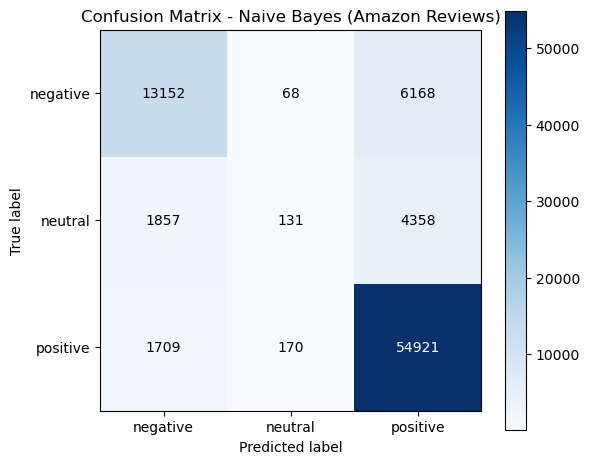

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix - Naive Bayes (Amazon Reviews)')

# Annotate each cell with its count
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### Conclusion

The Naive Bayes model reaches a solid overall accuracy on this large (400K+), heavily imbalanced review set, doing very well on the dominant *positive* class and reasonably on *negative* reviews. As the confusion matrix shows, the model struggles the most with the *neutral* class — it's both the smallest class and the hardest to separate from positive/negative sentiment based on word choice alone, since 3-star reviews often contain a mix of praise and complaints. This mirrors a common pattern in sentiment analysis: extreme sentiments (very positive/very negative) are easier to classify from word frequencies than genuinely mixed or lukewarm opinions.